In [1]:
%matplotlib inline
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import os
import numpy as np
warnings.filterwarnings('ignore')

In [2]:
pd.set_option('display.max_columns', 200)
pd.set_option('display.width', 150)

In [3]:
os.chdir("../") # set cwd to root dir

In [4]:
lf_control_df_02 = pd.read_csv("data/DUO-GAIT/processed/OG_st_control/sub_02/left_foot_core_params.csv")
lf_control_df_02.rename({ "timestamps": "Time (secs)" }, axis=1, inplace=True)
lf_control_df_02['Setup'] = 'Control + LF'

rf_control_df_02 = pd.read_csv("data/DUO-GAIT/processed/OG_st_control/sub_02/right_foot_core_params.csv")
rf_control_df_02.rename({ "timestamps": "Time (secs)" }, axis=1, inplace=True)
rf_control_df_02['Setup'] = 'Control + RF'

lf_fatigue_df_02 = pd.read_csv("data/DUO-GAIT/processed/OG_st_fatigue/sub_02/left_foot_core_params.csv")
lf_fatigue_df_02.rename({ "timestamps": "Time (secs)" }, axis=1, inplace=True)
lf_fatigue_df_02['Setup'] = 'Fatigue + LF'

rf_fatigue_df_02 = pd.read_csv("data/DUO-GAIT/processed/OG_st_fatigue/sub_02/right_foot_core_params.csv")
rf_fatigue_df_02.rename({ "timestamps": "Time (secs)" }, axis=1, inplace=True)
rf_fatigue_df_02['Setup'] = 'Fatigue + RF'

foot_df = pd.concat([lf_control_df_02, rf_control_df_02, lf_fatigue_df_02, rf_fatigue_df_02], axis=0)
foot_df

,stride_index,Time (secs),stride_lengths,clearances_min,clearances_max,stride_times,swing_times,stance_times,stance_ratios,fo_times,ic_times,fo_samples,ic_samples,is_outlier,turning_step,turning_interval,interrupted,Setup
0,0,2.80469,1.492164,0.004280,0.062994,1.10937,0.47656,0.63281,0.570423,3.43750,3.91406,440,501,False,False,True,False,Control + LF
1,1,3.91406,1.586318,0.002565,0.062007,1.09375,0.48437,0.60938,0.557147,4.52344,5.00781,579,641,False,False,True,False,Control + LF
2,2,5.00781,1.713094,0.028664,0.077349,1.07813,0.49219,0.58594,0.543478,5.59375,6.08594,716,779,False,False,False,False,Control + LF
3,3,6.08594,1.682749,0.001061,0.062864,1.07812,0.48437,0.59375,0.550727,6.67969,7.16406,855,917,False,False,False,False,Control + LF
4,4,7.16406,1.667110,0.014086,0.074089,1.07813,0.49219,0.58594,0.543478,7.75000,8.24219,992,1055,False,False,False,False,Control + LF
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
327,327,370.25000,1.541911,0.014123,0.064523,1.08594,0.49219,0.59375,0.546761,370.84375,371.33594,47468,47531,False,False,False,False,Fatigue + RF
328,328,371.33594,1.535646,0.022723,0.069562,1.04688,0.46094,0.58594,0.559701,371.92188,372.38282,47606,47665,False,False,False,False,Fatigue + RF
329,329,372.38282,1.511071,0.009347,0.063607,1.07031,0.46094,0.60937,0.569340,372.99219,373.45313,47743,47802,False,False,False,False,Fatigue + RF
330,330,373.45313,1.676061,0.017923,0.066817,1.07812,0.47656,0.60156,0.557971,374.05469,374.53125,47879,47940,False,False,True,False,Fatigue + RF


**Filter out outlier strides**

In [5]:
lf_control_df_02 = lf_control_df_02[lf_control_df_02['is_outlier']==False]
rf_control_df_02 = rf_control_df_02[rf_control_df_02['is_outlier']==False]
lf_fatigue_df_02 = lf_fatigue_df_02[lf_fatigue_df_02['is_outlier']==False]
rf_fatigue_df_02 = rf_fatigue_df_02[rf_fatigue_df_02['is_outlier']==False]
foot_df = foot_df[foot_df['is_outlier']==False]

**Samples for left foot during control walk**

In [6]:
print(lf_control_df_02['Time (secs)'].max(), "secs of walking session")
print(len(lf_control_df_02), "non outlier strides")
print(lf_control_df_02['ic_samples'].max(), "samples collected by IMU sensors (128 Hz)")

370.875 secs of walking session
305 non outlier strides
47609 samples collected by IMU sensors (128 Hz)


**Samples for left foot during fatigue walk**

In [7]:
print(lf_fatigue_df_02['Time (secs)'].max(), "secs of walking session")
print(len(lf_fatigue_df_02), "non outlier strides")
print(lf_fatigue_df_02['ic_samples'].max(), "samples collected by IMU sensors (128 Hz)")

374.0156299999999 secs of walking session
310 non outlier strides
48010 samples collected by IMU sensors (128 Hz)


<Axes: xlabel='stride_times'>

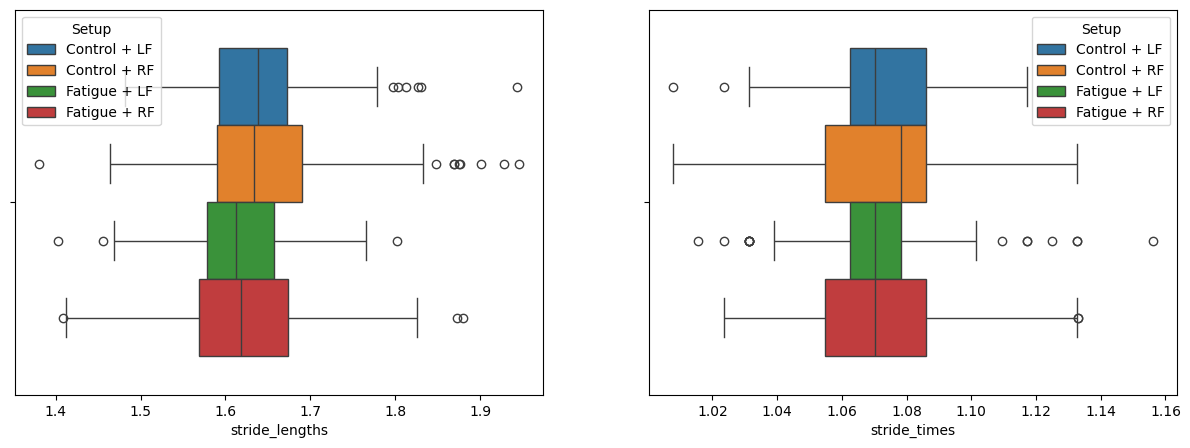

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

sns.boxplot(foot_df, x="stride_lengths", hue='Setup', ax=axes[0])
sns.boxplot(foot_df, x="stride_times", hue='Setup', ax=axes[1])

You have less stride length on average when fatigued. For stride time, it takes much longer to complete it during control. 

<Axes: xlabel='stance_times'>

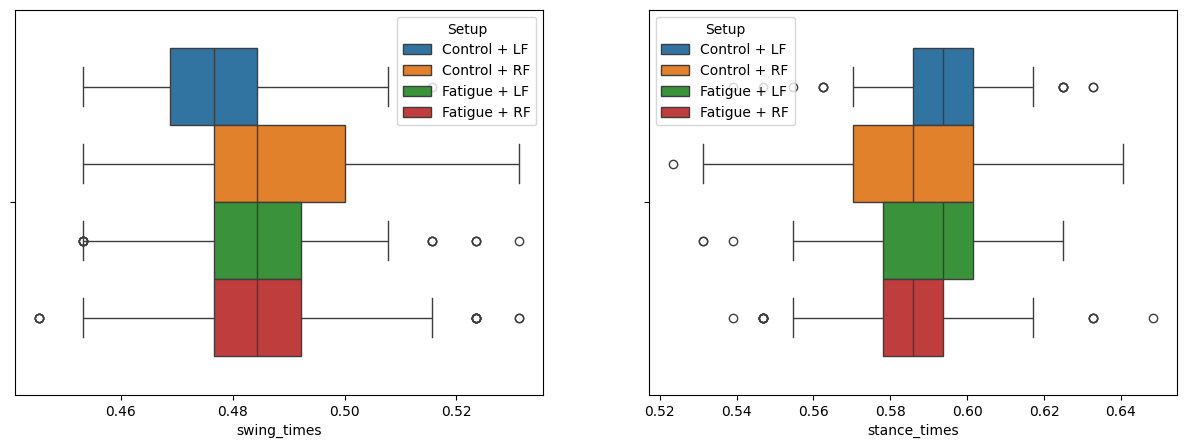

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

sns.boxplot(foot_df, x="swing_times", hue='Setup', ax=axes[0])
sns.boxplot(foot_df, x="stance_times", hue='Setup', ax=axes[1])

Swing time is much less for this person using the left foot during normal walk. Stance times are longer for left foot compared to right foot. This indicates a left foot dominance.

<Axes: xlabel='stance_ratios'>

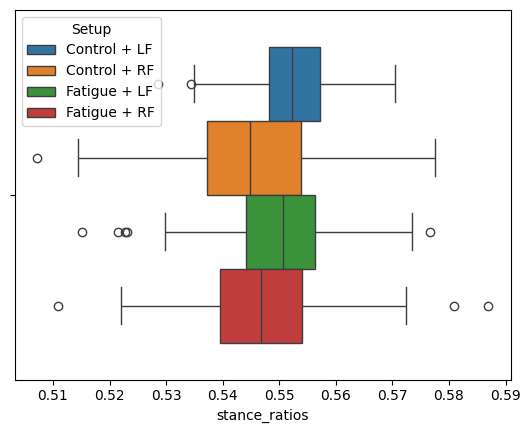

In [10]:
sns.boxplot(foot_df, x="stance_ratios", hue='Setup')

Another clear indication of left foot dominance. Body is mostly supported by left foot due having higher average ratio. 

<Axes: xlabel='clearances_max'>

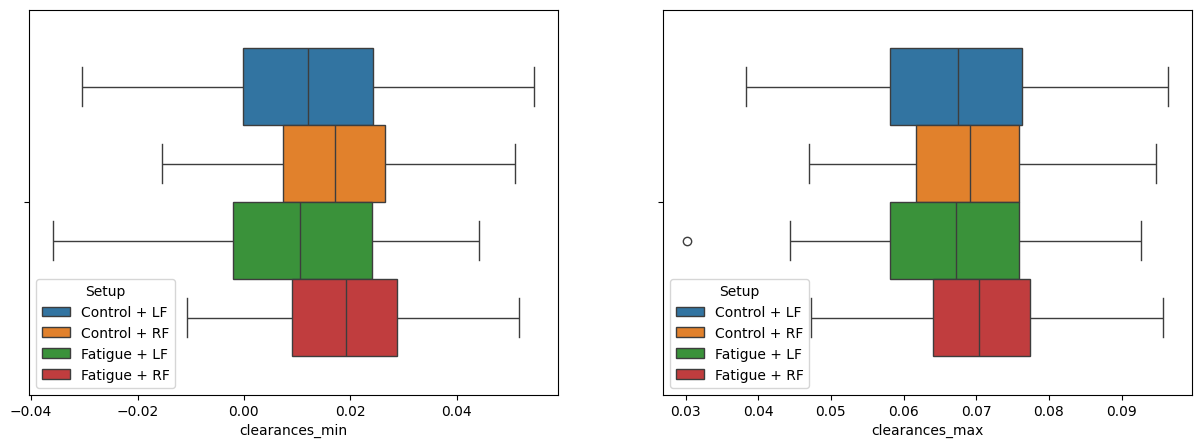

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

sns.boxplot(foot_df, x="clearances_min", hue='Setup', ax=axes[0])
sns.boxplot(foot_df, x="clearances_max", hue='Setup', ax=axes[1])

Left foot has lower clearance on average during mid swing compared to right foot. 